## EDA - Análisis Exploratorio

Tu EDA debería tener:

- Data overview - check
- Missing analysis - check
- Univariate distributions - check
- Outliers - check
- Target relationship - check
- Categorical analysis - check
- Correlation analysis - check
- Temporal stability - check
- Leakage detection - check
- Business sanity checks

Covers:

- Shape, dtypes, missing values
- Target distribution and class imbalance
- Temporal distribution of records and default rate per period
- Numeric feature distributions (histograms + box plots)
- Correlation heatmap
- Train / Test / Monitor split sizes

In [50]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

sns.set_theme(style= 'whitegrid', palette = 'muted')

#### Data Overview
- shape
- tipos de variables
- cardinalidad
- IDs (identificar si hay feature ID)
- duplicados (duplicado exacto de fila o duplicado de entiendad como 'customer_id' aparece varias veces puede ser correcto o incorrecto)
- constantes (detectar features constantes, es decir que tienen un solo valor, no aportan variación)
- missing %
- MCAR / MAR / MNAR
- sanity checks negocio (aunque el dato exista, tiene sentido? como ejm: edad negativa o igual a 150, income = 0)

In [10]:
with open("../params.yaml") as f:
    parameters = yaml.safe_load(f)

DATA = parameters["data"]
FEATURES = parameters["features"]
MODEL = parameters["model"]

NUMERIC = FEATURES["numeric"]
CATEGORICAL = FEATURES["categorical"]
TARGET = FEATURES["target"]

In [ ]:
class Preprocessing:
    def __init__(self):
        pass

In [13]:
df_train = pd.read_csv(f"{DATA['train_data']}")
df_train.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [47]:
## shape, dtype, cardinalidad (unicos), duplicates, % missings

## Numeric
shape_rows = df_train.shape[0]
duplicates = df_train.duplicated().sum()
dtype_num = [d for d in df_train[NUMERIC].dtypes.astype("str").tolist()]
cardinalidad_num = [len(df_train[d].unique()) for d in NUMERIC]
missings_num = [round(((df_train[d].isnull().sum()/shape_rows)*100), 2) for d in NUMERIC]

dtype_cat = [d for d in df_train[CATEGORICAL].dtypes.astype("str").tolist()]
cardinalidad_cat = [len(df_train[d].unique()) for d in CATEGORICAL]
missings_cat = [round(((df_train[d].isnull().sum()/shape_rows)*100), 2) for d in CATEGORICAL]


data_overview_num = pd.DataFrame({
    "Tipo Variable": dtype_num,
    "Valores Únicos": cardinalidad_num,
    "%Missings": missings_num
}, index= NUMERIC).sort_values(by="%Missings", ascending = False)

data_overview_cat = pd.DataFrame({
    "Tipo Variable": dtype_cat,
    "Valores Únicos": cardinalidad_cat,
    "%Missings": missings_cat
}, index= CATEGORICAL).sort_values(by="%Missings", ascending = False)



print("=== Vista General ===")
print(f'Tamaño del dataset       : {shape_rows} filas')
print(f'Cantidad de duplicados   : {duplicates} duplicados')
print('')
print("=== Features Numéricas ===")
display(data_overview_num)
print('=== Features Categóricas ===')
display(data_overview_cat)


=== Vista General ===
Tamaño del dataset       : 45528 filas
Cantidad de duplicados   : 0 duplicados

=== Features Numéricas ===


,Tipo Variable,Valores Únicos,%Missings
no_of_children,float64,11,1.70
no_of_days_employed,float64,7875,1.02
yearly_debt_payments,float64,45252,0.21
migrant_worker,float64,3,0.19
total_family_members,float64,11,0.18
credit_score,float64,451,0.02
age,int64,33,0.00
net_yearly_income,float64,45502,0.00
credit_limit,float64,45371,0.00
credit_limit_used(%),int64,100,0.00


=== Features Categóricas ===


,Tipo Variable,Valores Únicos,%Missings
owns_car,object,3,1.2
name,object,4010,0.0
gender,object,3,0.0
owns_house,object,2,0.0
occupation_type,object,19,0.0


#### Distribución del Target y balanceamiento

In [ ]:


df_train[TARGET].value_counts(normalize = True)

default_in_last_6months
0    0.94946
1    0.05054
Name: proportion, dtype: float64

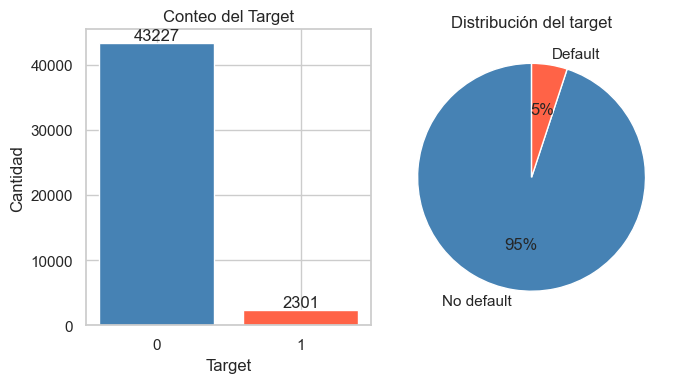

In [80]:
fig, ax = plt.subplots(nrows= 1, ncols= 2, figsize = (7, 4))

bars = ax[0].bar(
    x = [0, 1],
    height= df_train[TARGET].value_counts(),
    color = ["steelblue", "tomato"]
)

ax[0].bar_label(bars, fmt = "%d")
ax[0].set(title = 'Conteo del Target', ylabel = 'Cantidad', xlabel = 'Target')
ax[0].set_xticks([0, 1])

ax[1].pie(
    x = df_train[TARGET].value_counts(),
    labels = ["No default", "Default"],
    colors = ["steelblue", "tomato"],
    autopct = "%.0f%%",
    startangle = 90
)
ax[1].set_title("Distribución del target")

plt.tight_layout()
plt.show()



#### Distribución temporal de los registros y default rate por período

#### Distribución de las features numéricas

#### Análisis de correlación

#### Train / Test / Monitor split sizes